# 🤖 AutoGen Data Analyzer GPT — Full Pipeline Notebook

**End-to-end Google Colab implementation** of the AutoGen Data Analysis System.

## Pipeline Stages
| Stage | Description |
|---|---|
| 0 | Load API Keys from Colab Secrets |
| 1 | Install Dependencies |
| 2 | Create Project Structure |
| 3 | Write `src/utils/` (logger + custom exception) |
| 4 | Write `src/config/` (constants + model clients) |
| 5 | Write `src/agents/prompts/DataAnalyzerAgentPrompt.py` |
| 6 | Write `src/agents/` (DataAnalyzer + CodeExecutor agents) |
| 7 | Write `src/team/analyzer_gpt.py` |
| 8 | Write `main.py` + `setup.py` + `requirements.txt` |
| 9 | Upload CSV + Run Full Analysis Pipeline |
| 10 | Display Outputs & Zip Download |

> **LLM Options:** Groq `llama-3.3-70b-versatile` (primary, free) · OpenAI `gpt-4o` (fallback)  
> **Execution:** Local `LocalCommandLineCodeExecutor` (no Docker needed in Colab)  
> **Agent Framework:** Microsoft AutoGen v0.4 (`autogen-agentchat`, `autogen-ext`)


## 🏗️ Architecture Overview

```text
User Task (natural language query about CSV)
        │
        ▼
  RoundRobinGroupChat (team/analyzer_gpt.py)
  ┌─────────────────────────────────────────┐
  │  Turn 1 → Data_Analyzer_Agent           │
  │           (LLM: Groq / OpenAI)          │
  │           → Writes Python/bash code     │
  │                                         │
  │  Turn 2 → CodeExecutor Agent            │
  │           (LocalCommandLineCodeExecutor) │
  │           → Executes code, returns output│
  │                                         │
  │  Repeats until 'STOP' or max_turns      │
  └─────────────────────────────────────────┘
        │
        ▼
  Output (text analysis + output.png saved to temp/)
```

### Project Structure
```text
AutoGen_Data_Analyzer/
├── src/
│   ├── agents/
│   │   ├── prompts/
│   │   │   └── DataAnalyzerAgentPrompt.py
│   │   ├── Data_analyzer_agent.py
│   │   └── Code_Executor_agent.py
│   ├── config/
│   │   ├── constants.py
│   │   ├── groq_model_client.py
│   │   └── openai_model_client.py
│   ├── team/
│   │   └── analyzer_gpt.py
│   └── utils/
│       ├── logger.py
│       └── custom_exception.py
├── temp/                    ← CSV + generated outputs land here
├── main.py
├── setup.py
└── requirements.txt
```


## 🔑 Stage 0 — Load API Keys from Colab Secrets

In [2]:
# Stage 0: Load keys from Colab Secrets
# In Colab: Runtime → Secrets → add GROQ_API_KEY and/or OPENAI_API_KEY
import os

try:
    from google.colab import userdata
    os.environ['GROQ_API_KEY']   = userdata.get('GROQ_API_KEY')
    os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
    print('✅ Keys loaded from Colab Secrets')
except Exception:
    # Fallback: set manually for local runs
    os.environ['GROQ_API_KEY']   = 'your-groq-api-key-here'
    os.environ['OPENAI_API_KEY'] = 'your-openai-api-key-here'
    print('⚠️  Keys set manually — replace with your actual keys')

print('GROQ_API_KEY  :', 'set ✅' if os.environ.get('GROQ_API_KEY') else 'MISSING ❌')
print('OPENAI_API_KEY:', 'set ✅' if os.environ.get('OPENAI_API_KEY') else 'MISSING ❌')


⚠️  Keys set manually — replace with your actual keys
GROQ_API_KEY  : set ✅
OPENAI_API_KEY: set ✅


## ⚙️ Stage 1 — Install Dependencies

In [3]:
# Stage 1: Install all required packages
# autogen-ext[local] gives LocalCommandLineCodeExecutor (no Docker needed in Colab)
!pip install -q \
    autogen-agentchat \
    autogen-core \
    'autogen-ext[openai]' \
    'autogen-ext[local]' \
    groq \
    openai \
    tiktoken \
    python-dotenv \
    pandas \
    matplotlib \
    seaborn

print('✅ All packages installed')


✅ All packages installed


In [7]:
import os

try:
    from google.colab import userdata
    key = userdata.get("GROQ_API_KEY")

    if key:  # only set if exists
        os.environ["GROQ_API_KEY"] = key.strip()
        print("✅ GROQ key loaded from Colab Secrets")
    else:
        print("❌ GROQ key not found in Secrets")

except Exception as e:
    print("❌ Error loading secrets:", e)

✅ GROQ key loaded from Colab Secrets


In [12]:
from groq import Groq
import os

client = Groq(api_key=os.environ["GROQ_API_KEY"])

res = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": "Reply with OK"}],
    max_tokens=5
)

print(res.choices[0].message.content)

OK


In [13]:
# Verify key package versions
from importlib.metadata import version, PackageNotFoundError

PKGS = [
    'autogen-agentchat', 'autogen-core', 'autogen-ext',
    'openai', 'groq', 'tiktoken', 'pandas', 'matplotlib', 'seaborn'
]

for pkg in PKGS:
    try:
        print(f'  {pkg:30} == {version(pkg)}')
    except PackageNotFoundError:
        print(f'  {pkg:30} NOT INSTALLED ❌')

print('✅ Version check complete')


  autogen-agentchat              == 0.7.5
  autogen-core                   == 0.7.5
  autogen-ext                    == 0.7.5
  openai                         == 2.30.0
  groq                           == 1.1.2
  tiktoken                       == 0.12.0
  pandas                         == 2.2.2
  matplotlib                     == 3.10.0
  seaborn                        == 0.13.2
✅ Version check complete


## 🗂️ Stage 2 — Create Project Structure

In [14]:
# Stage 2: Mirror the production folder structure
import os

dirs = [
    'src/agents/prompts',
    'src/config',
    'src/team',
    'src/utils',
    'temp',
]
for d in dirs:
    os.makedirs(d, exist_ok=True)

# __init__.py for all packages
for pkg in ['src', 'src/agents', 'src/agents/prompts',
            'src/config', 'src/team', 'src/utils']:
    init = os.path.join(pkg, '__init__.py')
    if not os.path.exists(init):
        open(init, 'w').close()

print('✅ Project structure created:')
for d in dirs:
    print(f'   {d}/')


✅ Project structure created:
   src/agents/prompts/
   src/config/
   src/team/
   src/utils/
   temp/


## 🛠️ Stage 3 — Write `src/utils/` (Logger + Custom Exception)

In [15]:
# Stage 3a: Write src/utils/logger.py
logger_code = '''
import logging
import os
from datetime import datetime

LOGS_DIR = "logs"
os.makedirs(LOGS_DIR, exist_ok=True)

LOG_FILE = os.path.join(LOGS_DIR, f"log_{datetime.now().strftime('%Y-%m-%d')}.log")

logging.basicConfig(
    filename=LOG_FILE,
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    level=logging.INFO
)

def get_logger(name: str):
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    return logger
'''

with open('src/utils/logger.py', 'w') as f:
    f.write(logger_code.strip())

print('✅ src/utils/logger.py written')


✅ src/utils/logger.py written


In [16]:
# Stage 3b: Write src/utils/custom_exception.py
exc_code = '''
import sys

class CustomException(Exception):
    def __init__(self, message: str, error_detail: Exception = None):
        self.error_message = self._build_message(message, error_detail)
        super().__init__(self.error_message)

    @staticmethod
    def _build_message(message, error_detail):
        _, _, exc_tb = sys.exc_info()
        file_name   = exc_tb.tb_frame.f_code.co_filename if exc_tb else "Unknown"
        line_number = exc_tb.tb_lineno if exc_tb else "Unknown"
        return (
            f"{message} | Error: {error_detail} "
            f"| File: {file_name} | Line: {line_number}"
        )

    def __str__(self):
        return self.error_message
'''

with open('src/utils/custom_exception.py', 'w') as f:
    f.write(exc_code.strip())

print('✅ src/utils/custom_exception.py written')


✅ src/utils/custom_exception.py written


In [17]:
# Stage 3c: Verify utils imports
import sys
sys.path.insert(0, 'src')

from utils.logger import get_logger
from utils.custom_exception import CustomException

logger = get_logger('pipeline')
logger.info('AutoGen Data Analyzer pipeline notebook started')
print('✅ Logger and CustomException imported successfully')


INFO:pipeline:AutoGen Data Analyzer pipeline notebook started


✅ Logger and CustomException imported successfully


## ⚙️ Stage 4 — Write `src/config/` (Constants + Model Clients)

Two model clients are provided:
- **Groq** (`groq_model_client.py`) — uses `llama-3.3-70b-versatile` via OpenAI-compatible endpoint
- **OpenAI** (`openai_model_client.py`) — uses `gpt-4o`

Set `USE_GROQ = True` (default) in the pipeline cell to choose.


In [18]:
# Stage 4a: Write src/config/constants.py
constants_code = '''
# Execution settings
WORK_DIR       = "temp"      # Directory for code execution & file outputs
TIMEOUT_EXEC   = 120        # Max seconds per code execution block
MAX_TURNS      = 15         # Max agent conversation rounds
TERMINATION_KW = "STOP"     # Keyword that ends the conversation

# Model identifiers
GROQ_MODEL   = "llama-3.3-70b-versatile"
OPENAI_MODEL = "gpt-4o"
TEMPERATURE  = 0.3
'''

with open('src/config/constants.py', 'w') as f:
    f.write(constants_code.strip())

print('✅ src/config/constants.py written')


✅ src/config/constants.py written


In [19]:
# Stage 4b: Write src/config/groq_model_client.py
# Groq exposes an OpenAI-compatible API endpoint — we use OpenAIChatCompletionClient
# with the Groq base_url and llama-3.3-70b-versatile model.
groq_client_code = '''
import os
from autogen_ext.models.openai import OpenAIChatCompletionClient
from config.constants import GROQ_MODEL, TEMPERATURE

def get_groq_model_client():
    api_key = os.environ.get("GROQ_API_KEY", "")
    if not api_key:
        raise EnvironmentError("GROQ_API_KEY not set in environment variables.")

    client = OpenAIChatCompletionClient(
        model=GROQ_MODEL,
        api_key=api_key,
        base_url="https://api.groq.com/openai/v1",
        model_capabilities={
            "vision": False,
            "function_calling": True,
            "json_output": True,
        },
    )
    return client
'''

with open('src/config/groq_model_client.py', 'w') as f:
    f.write(groq_client_code.strip())

print('✅ src/config/groq_model_client.py written')


✅ src/config/groq_model_client.py written


In [20]:
# Stage 4c: Write src/config/openai_model_client.py
openai_client_code = '''
import os
from autogen_ext.models.openai import OpenAIChatCompletionClient
from config.constants import OPENAI_MODEL, TEMPERATURE

def get_openai_model_client():
    api_key = os.environ.get("OPENAI_API_KEY", "")
    if not api_key:
        raise EnvironmentError("OPENAI_API_KEY not set in environment variables.")

    client = OpenAIChatCompletionClient(
        model=OPENAI_MODEL,
        api_key=api_key,
    )
    return client
'''

with open('src/config/openai_model_client.py', 'w') as f:
    f.write(openai_client_code.strip())

print('✅ src/config/openai_model_client.py written')


✅ src/config/openai_model_client.py written


In [21]:
# Stage 4d: Verify config imports
from config.constants import (
    WORK_DIR, TIMEOUT_EXEC, MAX_TURNS, TERMINATION_KW,
    GROQ_MODEL, OPENAI_MODEL, TEMPERATURE
)

print('✅ config/constants imported:')
print(f'   WORK_DIR      = {WORK_DIR}')
print(f'   TIMEOUT_EXEC  = {TIMEOUT_EXEC}s')
print(f'   MAX_TURNS     = {MAX_TURNS}')
print(f'   GROQ_MODEL    = {GROQ_MODEL}')
print(f'   OPENAI_MODEL  = {OPENAI_MODEL}')


✅ config/constants imported:
   WORK_DIR      = temp
   TIMEOUT_EXEC  = 120s
   MAX_TURNS     = 15
   GROQ_MODEL    = llama-3.3-70b-versatile
   OPENAI_MODEL  = gpt-4o


## 📝 Stage 5 — Write `src/agents/prompts/DataAnalyzerAgentPrompt.py`

In [22]:
# Stage 5: Write the system prompt for the Data Analyzer Agent
prompt_code = '''
DATA_ANALYZER_MSG = \'\'\'\n",
    "You are a Data Analyst agent with expertise in Python and working with CSV data.\n",
    "The CSV file will be located at \'data.csv\' inside the working directory.\n",
    "You will receive a user question about this data.\n",
    "Your job is to write Python code to answer the question.\n",
    "\n",
    "Follow these rules STRICTLY:\n",
    "\n",
    "1. PLAN FIRST: Briefly explain in 1-2 sentences how you will solve the problem.\n",
    "\n",
    "2. WRITE CODE: Produce exactly ONE Python code block:\n",
    "   ```python\n",
    "   your-code-here\n",
    "   ```\n",
    "   Always end code with a print statement confirming task completion.\n",
    "\n",
    "3. WAIT: After writing the code, STOP and wait for CodeExecutor to run it.\n",
    "\n",
    "4. INSTALL MISSING LIBS: If a library is missing, send a bash block first:\n",
    "   ```bash\n",
    "   pip install pandas matplotlib seaborn\n",
    "   ```\n",
    "   Then resend the Python code block.\n",
    "\n",
    "5. ANALYZE OUTPUT: After execution, interpret results for the user clearly.\n",
    "\n",
    "6. SAVE PLOTS: If the task involves a chart or visualization, use matplotlib\n",
    "   and ALWAYS save as \'output.png\' with plt.savefig(\'output.png\').\n",
    "\n",
    "7. FINISH: When the task is fully complete, end your final message with \'STOP\'.\n",
    "\n",
    "Collaborate smoothly with the CodeExecutor agent.\n",
    "\'\'\'\n",
    "'''

# Write the actual file with correct Python syntax
actual_prompt = '''DATA_ANALYZER_MSG = """
You are a Data Analyst agent with expertise in Python and working with CSV data.
The CSV file will be located at 'data.csv' inside the working directory.
You will receive a user question about this data.
Your job is to write Python code to answer the question.

Follow these rules STRICTLY:

1. PLAN FIRST: Briefly explain in 1-2 sentences how you will solve the problem.

2. WRITE CODE: Produce exactly ONE Python code block:
   ```python
   your-code-here
   ```
   Always end code with a print statement confirming task completion.

3. WAIT: After writing the code, STOP and wait for CodeExecutor to run it.

4. INSTALL MISSING LIBS: If a library is missing, send a bash block first:
   ```bash
   pip install pandas matplotlib seaborn
   ```
   Then resend the Python code block.

5. ANALYZE OUTPUT: After execution, interpret results for the user clearly.

6. SAVE PLOTS: If the task involves a chart or visualization, use matplotlib
   and ALWAYS save as 'output.png' with plt.savefig('output.png').

7. FINISH: When the task is fully complete, end your final message with 'STOP'.

Collaborate smoothly with the CodeExecutor agent.
"""
'''

with open('src/agents/prompts/DataAnalyzerAgentPrompt.py', 'w') as f:
    f.write(actual_prompt.strip())

print('✅ src/agents/prompts/DataAnalyzerAgentPrompt.py written')


✅ src/agents/prompts/DataAnalyzerAgentPrompt.py written


## 🤖 Stage 6 — Write `src/agents/` (DataAnalyzer + CodeExecutor)

**Key design choice — no Docker in Colab:**  
The original project used `DockerCommandLineCodeExecutor`. In Colab, Docker is not available.  
We replace it with `LocalCommandLineCodeExecutor` from `autogen-ext[local]` — same interface, runs locally.


In [23]:
# Stage 6a: Write src/agents/Data_analyzer_agent.py
data_agent_code = '''
from autogen_agentchat.agents import AssistantAgent
from agents.prompts.DataAnalyzerAgentPrompt import DATA_ANALYZER_MSG
from utils.logger import get_logger

logger = get_logger(__name__)

def getDataAnalyzerAgent(model_client):
    data_analyzer_agent = AssistantAgent(
        name="Data_Analyzer_Agent",
        description="An agent which helps with solving Data Analysis tasks and writes Python code.",
        model_client=model_client,
        system_message=DATA_ANALYZER_MSG,
    )
    logger.info("DataAnalyzerAgent initialized")
    return data_analyzer_agent
'''

with open('src/agents/Data_analyzer_agent.py', 'w') as f:
    f.write(data_agent_code.strip())

print('✅ src/agents/Data_analyzer_agent.py written')


✅ src/agents/Data_analyzer_agent.py written


In [24]:
# Stage 6b: Write src/agents/Code_Executor_agent.py
# Uses LocalCommandLineCodeExecutor (Colab-compatible replacement for Docker)
code_agent_code = '''
from autogen_agentchat.agents import CodeExecutorAgent
from autogen_ext.code_executors.local import LocalCommandLineCodeExecutor
from config.constants import WORK_DIR, TIMEOUT_EXEC
from utils.logger import get_logger
import os

logger = get_logger(__name__)

def getLocalCodeExecutor():
    os.makedirs(WORK_DIR, exist_ok=True)
    executor = LocalCommandLineCodeExecutor(
        work_dir=WORK_DIR,
        timeout=TIMEOUT_EXEC,
    )
    logger.info(f"LocalCommandLineCodeExecutor ready | work_dir={WORK_DIR}")
    return executor

def getCodeExecutorAgent(code_executor):
    agent = CodeExecutorAgent(
        name="CodeExecutor",
        code_executor=code_executor,
    )
    logger.info("CodeExecutorAgent initialized")
    return agent
'''

with open('src/agents/Code_Executor_agent.py', 'w') as f:
    f.write(code_agent_code.strip())

print('✅ src/agents/Code_Executor_agent.py written')


✅ src/agents/Code_Executor_agent.py written


In [25]:
# Stage 6c: Verify agent imports
from agents.Data_analyzer_agent import getDataAnalyzerAgent
from agents.Code_Executor_agent import getLocalCodeExecutor, getCodeExecutorAgent
print('✅ Agent modules imported successfully')


✅ Agent modules imported successfully


## 👥 Stage 7 — Write `src/team/analyzer_gpt.py`

In [26]:
# Stage 7: Write src/team/analyzer_gpt.py
team_code = '''
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.conditions import TextMentionTermination
from agents.Data_analyzer_agent import getDataAnalyzerAgent
from agents.Code_Executor_agent import getCodeExecutorAgent
from config.constants import MAX_TURNS, TERMINATION_KW
from utils.logger import get_logger

logger = get_logger(__name__)

def getDataAnalyzerTeam(code_executor, model_client):
    """Build and return a RoundRobinGroupChat team.

    Turn order: Data_Analyzer_Agent → CodeExecutor → repeat
    Terminates when LLM outputs the TERMINATION_KW or MAX_TURNS reached.
    """
    data_analyzer_agent = getDataAnalyzerAgent(model_client)
    code_executor_agent = getCodeExecutorAgent(code_executor)

    termination = TextMentionTermination(TERMINATION_KW)

    team = RoundRobinGroupChat(
        participants=[data_analyzer_agent, code_executor_agent],
        max_turns=MAX_TURNS,
        termination_condition=termination,
    )
    logger.info("DataAnalyzerTeam built | max_turns=%d", MAX_TURNS)
    return team
'''

with open('src/team/analyzer_gpt.py', 'w') as f:
    f.write(team_code.strip())

print('✅ src/team/analyzer_gpt.py written')


✅ src/team/analyzer_gpt.py written


In [27]:
# Stage 7b: Verify team import
from team.analyzer_gpt import getDataAnalyzerTeam
print('✅ team/analyzer_gpt imported successfully')


✅ team/analyzer_gpt imported successfully


## 🖥️ Stage 8 — Write `main.py`, `setup.py`, `requirements.txt`

In [28]:
# Stage 8a: Write main.py
main_code = '''
import asyncio
import os
import sys

sys.path.insert(0, "src")

from team.analyzer_gpt import getDataAnalyzerTeam
from agents.Code_Executor_agent import getLocalCodeExecutor
from config.constants import WORK_DIR
from utils.logger import get_logger

from autogen_agentchat.messages import TextMessage
from autogen_agentchat.base import TaskResult

logger = get_logger(__name__)

# ── LLM Selection ──────────────────────────────────────────────────────────
# Set USE_GROQ = True  → Groq llama-3.3-70b-versatile (free, fast)
# Set USE_GROQ = False → OpenAI gpt-4o
USE_GROQ = True

if USE_GROQ:
    from config.groq_model_client import get_groq_model_client
    model_client = get_groq_model_client()
    print("Using LLM: Groq llama-3.3-70b-versatile")
else:
    from config.openai_model_client import get_openai_model_client
    model_client = get_openai_model_client()
    print("Using LLM: OpenAI gpt-4o")


async def main():
    os.makedirs(WORK_DIR, exist_ok=True)
    code_executor = getLocalCodeExecutor()
    team = getDataAnalyzerTeam(code_executor, model_client)

    task = (
        "Can you give me a graph of survived vs died from data.csv "
        "and save it as output.png?"
    )
    logger.info("Pipeline started | task: %s", task)

    async for message in team.run_stream(task=task):
        print("=" * 50)
        if isinstance(message, TextMessage):
            print(f"{message.source}: {message.content}")
        elif isinstance(message, TaskResult):
            print(f"Stop Reason: {message.stop_reason}")

    logger.info("Pipeline complete")


if __name__ == "__main__":
    asyncio.run(main())
'''

with open('main.py', 'w') as f:
    f.write(main_code.strip())

print('✅ main.py written')


✅ main.py written


In [29]:
# Stage 8b: Write requirements.txt
req = '''autogen-agentchat
autogen-core
autogen-ext[openai]
autogen-ext[local]
groq
openai
tiktoken
python-dotenv
pandas
matplotlib
seaborn
'''

with open('requirements.txt', 'w') as f:
    f.write(req.strip())

print('✅ requirements.txt written')


✅ requirements.txt written


In [30]:
# Stage 8c: Write setup.py
setup_code = '''
from setuptools import setup, find_packages

with open("requirements.txt") as f:
    requirements = [
        l.strip() for l in f
        if l.strip() and not l.startswith("#")
    ]

setup(
    name="autogen-data-analyzer-gpt",
    version="1.0.0",
    author="Your Name",
    description="AutoGen AI-Powered Data Analysis System",
    package_dir={"": "src"},
    packages=find_packages(where="src"),
    install_requires=requirements,
    python_requires=">=3.9",
)
'''

with open('setup.py', 'w') as f:
    f.write(setup_code.strip())

print('✅ setup.py written')


✅ setup.py written


## 🚀 Stage 9 — Upload CSV & Initialize LLM

**Step 1:** Upload your CSV file below (Titanic or any dataset).  
**Step 2:** Choose your LLM by setting `USE_GROQ = True` (Groq) or `False` (OpenAI).  
**Step 3:** Run the pipeline cell.


In [31]:
# Stage 9a: Upload CSV to temp/ directory
import os
import shutil

os.makedirs('temp', exist_ok=True)

try:
    from google.colab import files
    print('📂 Please upload your CSV file:')
    uploaded = files.upload()
    for filename, data in uploaded.items():
        dest = f'temp/data.csv'
        with open(dest, 'wb') as f:
            f.write(data)
        print(f'✅ Saved as temp/data.csv ({len(data):,} bytes) ← originally "{filename}"')
except Exception:
    # Local fallback: place your CSV at temp/data.csv manually
    print('⚠️  Not in Colab — place your CSV at temp/data.csv manually')

if os.path.exists('temp/data.csv'):
    import pandas as pd
    df = pd.read_csv('temp/data.csv')
    print(f'\n📊 Dataset preview: {df.shape[0]} rows × {df.shape[1]} columns')
    print('Columns:', list(df.columns))
    display(df.head(3))


📂 Please upload your CSV file:


Saving data.csv to data (1).csv
✅ Saved as temp/data.csv (60,302 bytes) ← originally "data (1).csv"

📊 Dataset preview: 891 rows × 12 columns
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [32]:
# Stage 9b: Initialize LLM client
# ── CHOOSE YOUR LLM HERE ───────────────────────────────────────────────────
USE_GROQ = True   # True → Groq (llama-3.3-70b-versatile) | False → OpenAI (gpt-4o)
# ──────────────────────────────────────────────────────────────────────────

import sys
sys.path.insert(0, 'src')

if USE_GROQ:
    from config.groq_model_client import get_groq_model_client
    model_client = get_groq_model_client()
    print('✅ LLM initialized: Groq llama-3.3-70b-versatile')
else:
    from config.openai_model_client import get_openai_model_client
    model_client = get_openai_model_client()
    print('✅ LLM initialized: OpenAI gpt-4o')


✅ LLM initialized: Groq llama-3.3-70b-versatile


/usr/local/lib/python3.12/dist-packages/autogen_ext/models/openai/_openai_client.py:466: UserWarning: Missing required field 'structured_output' in ModelInfo. This field will be required in a future version of AutoGen.
  validate_model_info(self._model_info)


In [33]:
# Stage 9c: Initialize Code Executor
from agents.Code_Executor_agent import getLocalCodeExecutor

code_executor = getLocalCodeExecutor()
print('✅ LocalCommandLineCodeExecutor ready | work_dir=temp/')


/content/src/agents/Code_Executor_agent.py:11: UserWarning: Using LocalCommandLineCodeExecutor may execute code on the local machine which can be unsafe. For security, it is recommended to use DockerCommandLineCodeExecutor instead. To install Docker, visit: https://docs.docker.com/get-docker/
  executor = LocalCommandLineCodeExecutor(
INFO:agents.Code_Executor_agent:LocalCommandLineCodeExecutor ready | work_dir=temp


✅ LocalCommandLineCodeExecutor ready | work_dir=temp/


## 🔄 Stage 9d — Run Analysis Pipeline

**State management:** The team state is saved after each run so conversation context persists across multiple queries in this session.


In [34]:
# Stage 9d: Run the full AutoGen pipeline
# State is preserved in `team_state` so context carries over between cells.

import asyncio
from team.analyzer_gpt import getDataAnalyzerTeam
from autogen_agentchat.messages import TextMessage
from autogen_agentchat.base import TaskResult

# ── Task — edit this to ask any question about your data ──────────────────
TASK = 'Can you give me a graph of survived vs died from data.csv and save it as output.png?'
# ─────────────────────────────────────────────────────────────────────────

# Global state store (persists across multiple pipeline runs in this session)
if 'team_state' not in dir():
    team_state = None


async def run_pipeline(task: str):
    global team_state

    team = getDataAnalyzerTeam(code_executor, model_client)

    # Restore prior conversation state if available
    if team_state is not None:
        try:
            await team.load_state(team_state)
            print('🔁 Prior team state restored')
        except Exception as e:
            print(f'⚠️  Could not restore state: {e}')

    print(f'\n🚀 Task: {task}\n' + '='*60)

    async for message in team.run_stream(task=task):
        print('─' * 50)
        if isinstance(message, TextMessage):
            print(f'[{message.source}]\n{message.content}')
        elif isinstance(message, TaskResult):
            print(f'\n✅ Pipeline finished | Stop reason: {message.stop_reason}')

    # Save state for next run
    team_state = await team.save_state()
    print('💾 Team state saved')


await run_pipeline(TASK)


INFO:agents.Data_analyzer_agent:DataAnalyzerAgent initialized
/content/src/agents/Code_Executor_agent.py:19: UserWarning: No approval function set for CodeExecutorAgent. This means code will be executed automatically without human oversight. For security, consider setting an approval_func to review and approve code before execution. See the CodeExecutorAgent documentation for examples of approval functions.
  agent = CodeExecutorAgent(
INFO:agents.Code_Executor_agent:CodeExecutorAgent initialized
INFO:team.analyzer_gpt:DataAnalyzerTeam built | max_turns=15



🚀 Task: Can you give me a graph of survived vs died from data.csv and save it as output.png?
──────────────────────────────────────────────────
[user]
Can you give me a graph of survived vs died from data.csv and save it as output.png?
──────────────────────────────────────────────────
[Data_Analyzer_Agent]
I will solve the problem by using the pandas library to read the CSV file and the matplotlib library to create a bar chart comparing the number of survived and died individuals. I will then save this chart as 'output.png'.

```python
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('data.csv')

# Count the number of survived and died individuals
survived_count = df['Survived'].value_counts()[1]
died_count = df['Survived'].value_counts()[0]

# Create a bar chart
plt.bar(['Survived', 'Died'], [survived_count, died_count])
plt.xlabel('Status')
plt.ylabel('Count')
plt.title('Survived vs Died')

# Save the chart as 'output.png'
plt.savefig('outpu

## 🔬 Stage 9e — Additional Analysis Queries

Run any of the cells below as follow-up questions. The team state is preserved so the agent has full prior context.


In [35]:
# Query 2: Survival by passenger class
TASK_2 = (
    'Show me survival rate by passenger class (Pclass) '
    'as a bar chart and save as output.png.'
)
await run_pipeline(TASK_2)


INFO:agents.Data_analyzer_agent:DataAnalyzerAgent initialized
/content/src/agents/Code_Executor_agent.py:19: UserWarning: No approval function set for CodeExecutorAgent. This means code will be executed automatically without human oversight. For security, consider setting an approval_func to review and approve code before execution. See the CodeExecutorAgent documentation for examples of approval functions.
  agent = CodeExecutorAgent(
INFO:agents.Code_Executor_agent:CodeExecutorAgent initialized
INFO:team.analyzer_gpt:DataAnalyzerTeam built | max_turns=15


🔁 Prior team state restored

🚀 Task: Show me survival rate by passenger class (Pclass) as a bar chart and save as output.png.
──────────────────────────────────────────────────
[user]
Show me survival rate by passenger class (Pclass) as a bar chart and save as output.png.
──────────────────────────────────────────────────
[CodeExecutor]
No code blocks found in the thread. Please provide at least one markdown-encoded code block to execute (i.e., quoting code in ```python or ```sh code blocks).
──────────────────────────────────────────────────
[Data_Analyzer_Agent]
I will solve the problem by using the pandas library to read the CSV file and calculate the survival rate for each passenger class, then use the matplotlib library to create a bar chart comparing these rates.

```python
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('data.csv')

# Calculate the survival rate for each passenger class
survival_rates = df.groupby('Pclass')['Survived'].m

In [36]:
# Query 3: Survival by gender
TASK_3 = (
    'Show me survival rate by gender (Sex column) '
    'as a bar chart and save as output.png.'
)
await run_pipeline(TASK_3)


INFO:agents.Data_analyzer_agent:DataAnalyzerAgent initialized
/content/src/agents/Code_Executor_agent.py:19: UserWarning: No approval function set for CodeExecutorAgent. This means code will be executed automatically without human oversight. For security, consider setting an approval_func to review and approve code before execution. See the CodeExecutorAgent documentation for examples of approval functions.
  agent = CodeExecutorAgent(
INFO:agents.Code_Executor_agent:CodeExecutorAgent initialized
INFO:team.analyzer_gpt:DataAnalyzerTeam built | max_turns=15


🔁 Prior team state restored

🚀 Task: Show me survival rate by gender (Sex column) as a bar chart and save as output.png.
──────────────────────────────────────────────────
[user]
Show me survival rate by gender (Sex column) as a bar chart and save as output.png.
──────────────────────────────────────────────────
[CodeExecutor]
No code blocks found in the thread. Please provide at least one markdown-encoded code block to execute (i.e., quoting code in ```python or ```sh code blocks).
──────────────────────────────────────────────────
[Data_Analyzer_Agent]
I will solve the problem by using the pandas library to read the CSV file and calculate the survival rate for each gender, then use the matplotlib library to create a bar chart comparing these rates.

```python
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('data.csv')

# Calculate the survival rate for each gender
survival_rates = df.groupby('Sex')['Survived'].mean()

# Create a bar chart
plt

In [37]:
# Query 4: Age distribution by survival
TASK_4 = (
    'Plot an age distribution histogram split by survival status '
    '(Survived=0 vs Survived=1) and save as output.png.'
)
await run_pipeline(TASK_4)


INFO:agents.Data_analyzer_agent:DataAnalyzerAgent initialized
/content/src/agents/Code_Executor_agent.py:19: UserWarning: No approval function set for CodeExecutorAgent. This means code will be executed automatically without human oversight. For security, consider setting an approval_func to review and approve code before execution. See the CodeExecutorAgent documentation for examples of approval functions.
  agent = CodeExecutorAgent(
INFO:agents.Code_Executor_agent:CodeExecutorAgent initialized
INFO:team.analyzer_gpt:DataAnalyzerTeam built | max_turns=15


🔁 Prior team state restored

🚀 Task: Plot an age distribution histogram split by survival status (Survived=0 vs Survived=1) and save as output.png.
──────────────────────────────────────────────────
[user]
Plot an age distribution histogram split by survival status (Survived=0 vs Survived=1) and save as output.png.
──────────────────────────────────────────────────
[CodeExecutor]
No code blocks found in the thread. Please provide at least one markdown-encoded code block to execute (i.e., quoting code in ```python or ```sh code blocks).
──────────────────────────────────────────────────
[Data_Analyzer_Agent]
I will solve the problem by using the pandas library to read the CSV file and the matplotlib library to create a histogram of age distribution split by survival status.

```python
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('data.csv')

# Create a histogram of age distribution split by survival status
plt.figure(figsize=(10,6))
plt.hist(

In [38]:
# Query 5: Summary statistics
TASK_5 = (
    'Give me a statistical summary of the dataset: '
    'average age, survival rate, gender split, and class distribution.'
)
await run_pipeline(TASK_5)


INFO:agents.Data_analyzer_agent:DataAnalyzerAgent initialized
/content/src/agents/Code_Executor_agent.py:19: UserWarning: No approval function set for CodeExecutorAgent. This means code will be executed automatically without human oversight. For security, consider setting an approval_func to review and approve code before execution. See the CodeExecutorAgent documentation for examples of approval functions.
  agent = CodeExecutorAgent(
INFO:agents.Code_Executor_agent:CodeExecutorAgent initialized
INFO:team.analyzer_gpt:DataAnalyzerTeam built | max_turns=15


🔁 Prior team state restored

🚀 Task: Give me a statistical summary of the dataset: average age, survival rate, gender split, and class distribution.
──────────────────────────────────────────────────
[user]
Give me a statistical summary of the dataset: average age, survival rate, gender split, and class distribution.
──────────────────────────────────────────────────
[CodeExecutor]
No code blocks found in the thread. Please provide at least one markdown-encoded code block to execute (i.e., quoting code in ```python or ```sh code blocks).
──────────────────────────────────────────────────
[Data_Analyzer_Agent]
I will solve the problem by using the pandas library to read the CSV file and calculate the statistical summary.

```python
import pandas as pd

# Read the CSV file
df = pd.read_csv('data.csv')

# Calculate the average age
average_age = df['Age'].mean()

# Calculate the survival rate
survival_rate = df['Survived'].mean()

# Calculate the gender split
gender_split = df['Sex'].value

## 📊 Stage 10 — Display Output & Download Project

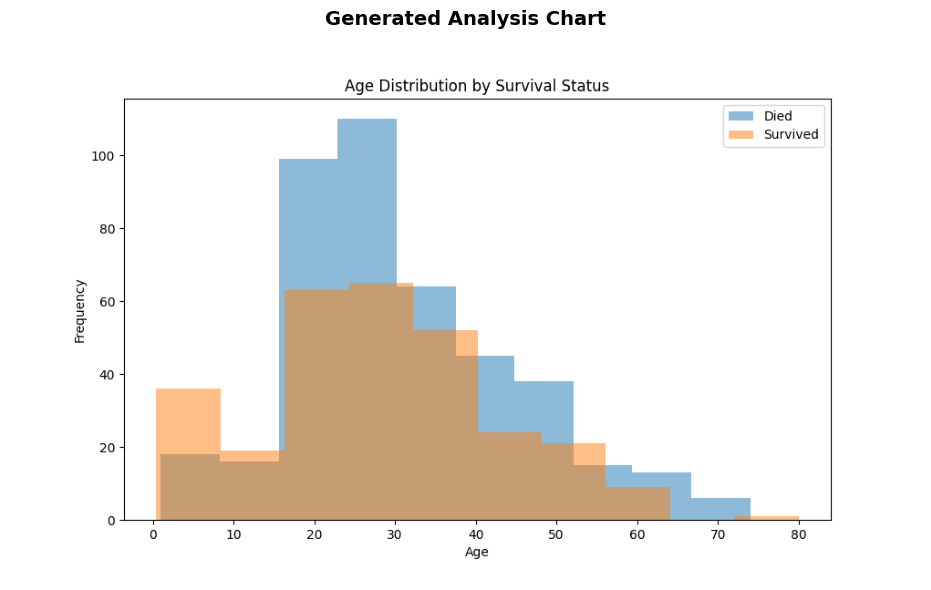

✅ output.png displayed


In [39]:
# Stage 10a: Display the last generated output.png
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

output_path = 'temp/output.png'

if os.path.exists(output_path):
    img = mpimg.imread(output_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Generated Analysis Chart', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('✅ output.png displayed')
else:
    print('⚠️  No output.png found yet — run a pipeline query first.')


In [40]:
# Stage 10b: List all generated files in temp/
import os

temp_files = os.listdir('temp') if os.path.exists('temp') else []
print(f'📁 Files in temp/ ({len(temp_files)} total):')
for f in sorted(temp_files):
    size = os.path.getsize(f'temp/{f}')
    print(f'   {f:60} {size:>8,} bytes')


📁 Files in temp/ (2 total):
   data.csv                                                       60,302 bytes
   output.png                                                     20,605 bytes


In [41]:
# Stage 10c: Save pipeline summary JSON
import json
from datetime import datetime

summary = {
    'pipeline_run': datetime.now().isoformat(),
    'llm_used': 'Groq llama-3.3-70b-versatile' if USE_GROQ else 'OpenAI gpt-4o',
    'executor': 'LocalCommandLineCodeExecutor',
    'tasks_run': [
        TASK,
        'Survival by passenger class',
        'Survival by gender',
        'Age distribution by survival',
        'Statistical summary',
    ],
    'output_files': sorted(os.listdir('temp')) if os.path.exists('temp') else []
}

with open('temp/pipeline_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('✅ Pipeline summary saved → temp/pipeline_summary.json')
print(json.dumps(summary, indent=2))


✅ Pipeline summary saved → temp/pipeline_summary.json
{
  "pipeline_run": "2026-04-08T04:08:27.629682",
  "llm_used": "Groq llama-3.3-70b-versatile",
  "executor": "LocalCommandLineCodeExecutor",
  "tasks_run": [
    "Can you give me a graph of survived vs died from data.csv and save it as output.png?",
    "Survival by passenger class",
    "Survival by gender",
    "Age distribution by survival",
    "Statistical summary"
  ],
  "output_files": [
    "data.csv",
    "output.png"
  ]
}


In [42]:
# Stage 10d: Zip entire project and download
import zipfile
import os

zip_path = 'AutoGen_Data_Analyzer_GPT.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    # Root files
    for fname in ['main.py', 'setup.py', 'requirements.txt']:
        if os.path.exists(fname):
            zf.write(fname)

    # src/ package (skip __pycache__)
    for root, dirs, fnames in os.walk('src'):
        dirs[:] = [d for d in dirs if d != '__pycache__']
        for fn in fnames:
            if not fn.endswith('.pyc'):
                zf.write(os.path.join(root, fn))

    # temp/ outputs (exclude raw CSV for size)
    for fn in os.listdir('temp') if os.path.exists('temp') else []:
        full = os.path.join('temp', fn)
        if not fn.endswith('.csv'):  # skip large CSV
            zf.write(full)

    # logs/
    if os.path.exists('logs'):
        for root, _, fnames in os.walk('logs'):
            for fn in fnames:
                zf.write(os.path.join(root, fn))

print(f'✅ Project zipped → {zip_path}')

try:
    from google.colab import files
    files.download(zip_path)
    print('📦 Download started!')
except Exception:
    print(f'💾 Zip saved locally at: {os.path.abspath(zip_path)}')


✅ Project zipped → AutoGen_Data_Analyzer_GPT.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 Download started!


In [43]:
import zipfile
import os
from google.colab import files

zip_filename = 'src_content.zip'
source_directory = 'src'

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files_in_dir in os.walk(source_directory):
        for file in files_in_dir:
            # Create an archive path that reflects the directory structure within the zip
            arcname = os.path.relpath(os.path.join(root, file), source_directory)
            zf.write(os.path.join(root, file), arcname=arcname)

print(f'✅ Zipped contents of {source_directory}/ to {zip_filename}')
files.download(zip_filename)
print('📦 Download started!')

✅ Zipped contents of src/ to src_content.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 Download started!


Listing and displaying outputs from temp/:

--- File: data.csv (60,302 bytes) ---
PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,,S
6,0,3,"Moran, Mr. James",male,,0,0,330877,8.4583,,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,,C
11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S
12,1,1,"Bonnell, Miss. Elizabeth",female

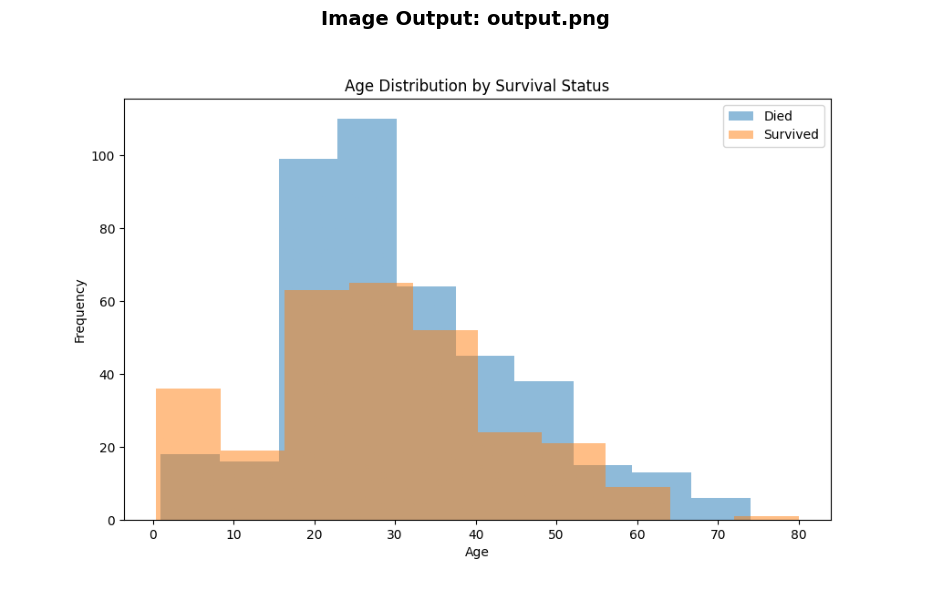


--- File: pipeline_summary.json (437 bytes) ---
{
  "pipeline_run": "2026-04-08T04:08:27.629682",
  "llm_used": "Groq llama-3.3-70b-versatile",
  "executor": "LocalCommandLineCodeExecutor",
  "tasks_run": [
    "Can you give me a graph of survived vs died from data.csv and save it as output.png?",
    "Survival by passenger class",
    "Survival by gender",
    "Age distribution by survival",
    "Statistical summary"
  ],
  "output_files": [
    "data.csv",
    "output.png"
  ]
}


In [44]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

output_dir = 'temp/'

print(f'Listing and displaying outputs from {output_dir}:')

if os.path.exists(output_dir):
    for filename in sorted(os.listdir(output_dir)):
        filepath = os.path.join(output_dir, filename)
        print(f'\n--- File: {filename} ({os.path.getsize(filepath):,} bytes) ---')

        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
            try:
                img = mpimg.imread(filepath)
                plt.figure(figsize=(10, 6))
                plt.imshow(img)
                plt.axis('off')
                plt.title(f'Image Output: {filename}', fontsize=14, fontweight='bold')
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f'Could not display image {filename}: {e}')
        else:
            try:
                with open(filepath, 'r') as f:
                    content = f.read()
                    print(content)
            except Exception as e:
                print(f'Could not read file {filename}: {e}')
else:
    print(f'Directory {output_dir} does not exist.')
